# Shortcut Segmentation

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Intro: Hair Segmentation
There are two possible ways in which hair appears in an image:
- Hair on skin but not the lesion region
- Hair on top of the lesion

As you've seen on `FYP2026_04_Morphology.ipynb`, if we were to create our own lesion masks using a simple thresholding method, the mask would not only capture the lesion region, but also the hair strands, due to the difference in intensity from the skin. In those cases, we've seen how to "clean" the mask using morphological operations such as **erosion** and **dilation**, or their combinations (**opening** and **closing**).

You probably observed that the masks we provided for your project are of pretty good quality. However, even though they isolate the lesion relatively well, the hair present in the selected region might interfere with some feature calculations, such as lesion color. We need to develop a method that identifies (better said, **segments**) that hair before the lesion is fed into a model. In other words, we need to develop a method to remove hair, as we care about lesion information only. To do so, we can use more advanced techniques like **BlackHat** and **TopHat** filtering.

*Note:* Both **BlackHat** and **TopHat** filtering techniques are not part of the regular course material this year. If you choose to use one of these in your project, you should be able to explain at a high level what it does, but you are not expected to give an in depth explanation of how it works internally.

**Let's create a hair mask by defining a simple hair segmentation function using BlackHat filtering (most common technique).**  



### BlackHat filtering  

**What is BlackHat filtering?**

- A hat transform is an operation that extracts small elements and details from given images.
- BlackHat is a technique in image processing that helps us find dark lines or spots (like hair) on a light background.
- First, it fills in small dark areas in the image using morphological closing.
- Then, it subtracts the original image from this filled-in version.
- The result is a mask that segments the dark features such as hair.

**Formula:**

$$
\text{BlackHat} = \text{Closing(image)} - \text{Original Image}
$$

**Remember closing and opening operations:**

An image processing operation that first applies a dilation (expands bright regions), then an erosion (shrinks bright regions). Used to fill small dark holes or gaps in bright objects, making the object smoother and more connected.

For more see [open CV docs](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)

In [7]:
def removeHair(img_org, img_gray, kernel_size=5, threshold=10, radius=3):

    # cross-shaped kernel for morphological operations (used to help detect thin dark structures)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))

    # perform the blackHat filtering on the grayscale image to find the hair contours
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)

    # segment the pixels where the difference between closing(image) and original image intensities is bigger than 10 
    _, mask = cv2.threshold(blackhat, threshold, 255, cv2.THRESH_BINARY)

    # fill in the white regions of the mask by using surrounding pixel information
    img_out = cv2.inpaint(img_org, mask, radius, cv2.INPAINT_TELEA)

    return blackhat, mask, img_out

**Now let's try to play around with couple of example pictures.**

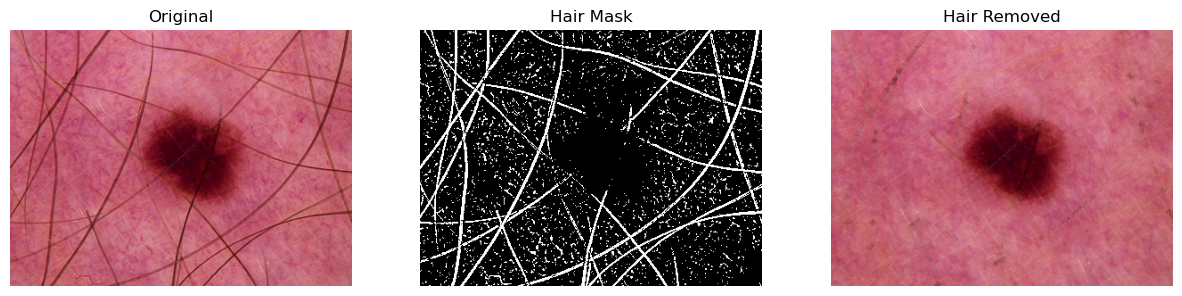

In [8]:
# load image 
img_path = 'black_hair.png'
img_org = cv2.imread(img_path) # loads the image in BGR format
img_org = cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)  # convert to RGB for matplotlib
img_gray = cv2.cvtColor(img_org, cv2.COLOR_RGB2GRAY) # convert to grayscale for processing

# use the removeHair function
blackhat, hair_mask, img_hair_removed = removeHair(img_org, img_gray)

# show results
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img_org)
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hair_mask, cmap='gray')
plt.title('Hair Mask')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_hair_removed)
plt.title('Hair Removed')
plt.axis('off')

plt.show()

**As you can see, there are still some hair artifacts left after processing. Try adjusting function parameters to find the best settings.**

Try answering the following questions:
1. What does each parameter control in the hair removal function? 
2. How does increasing and decreasing of each parameter affect hair detection?

# Adjusting parameters

The main factor that affects how you set the parameters is the amount of hair in each image. As you go through the dataset, you will notice that some images have a lot of hair, while others have very little. This means there is no single set of parameters that works for every image, they need to be adjusted based on how much hair is present.

Previously, we learned how to extract a hair mask from an image. Now, your task is to create a function that calculates the ratio of hair in the image. This ratio can help you automatically adjust the parameters for hair removal, making the process more efficient.

**You can perfome the following steps to calculate hair coverage:**
1. Highlight hair
2. Calculate area that hair takes up
3. Calculate the total area of an image 
4. Get a ratio

**Hint:**

Methods for highlighting hair:

- *Morphological BlackHat filtering:* same function as used in the hair removal function, you can start with default BlackHat parameters to get an initial hair mask and calculate hair coverage from this mask. If coverage is high, you adjust parameters that suits the image better.
- *Edge detection:* more advanced techniques that use gradients, such as [Sobel](https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html) and [Laplacian](https://docs.opencv.org/4.x/d5/db5/tutorial_laplace_operator.html)
- Any other ideas are welcome too :)

In [ ]:
def hair_coverage(img_gray):

    # generate hair mask using BlackHat filtering
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    total_area = # your code
    hair_area = # your code
    coverage = # your code
    
    return round(coverage, 4)

**Try out your function on image with and without hair.**

Hair coverage (with hair): 0.1467
Hair coverage (without hair): 0.0116


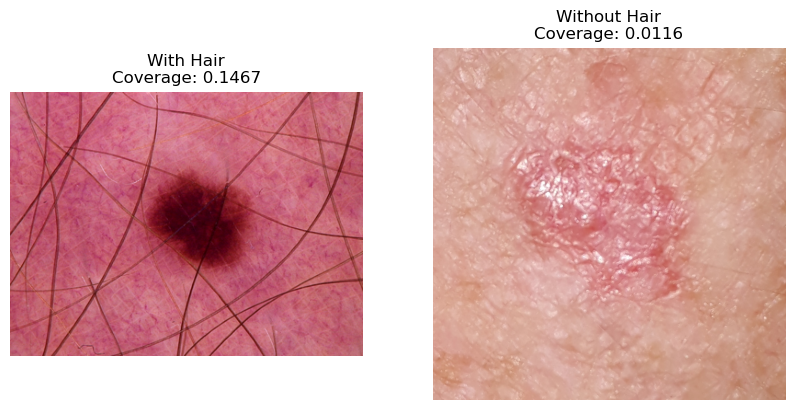

In [ ]:
# Load image with hair
img_path_hair = 'black_hair.png'
img_org_hair = cv2.imread(img_path_hair) 
img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)

# Load image without hair
img_path_nohair = 'no_hair.png'
img_org_nohair = cv2.imread(img_path_nohair)
img_gray_nohair = cv2.cvtColor(img_org_nohair, cv2.COLOR_BGR2GRAY)

# Calculate hair coverage for both images
coverage_hair = hair_coverage(img_gray_hair)
coverage_nohair = hair_coverage(img_gray_nohair)

# Show results
print(f"Hair coverage (with hair): {coverage_hair}")
print(f"Hair coverage (without hair): {coverage_nohair}")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2RGB))
plt.title(f'With Hair\nCoverage: {coverage_hair}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_org_nohair, cv2.COLOR_BGR2RGB))
plt.title(f'Without Hair\nCoverage: {coverage_nohair}')
plt.axis('off')

plt.show()

**Question:**
- How could you verify that the hair coverage is working on different hair amounts on bigger scale (not only just looking at few pictures at the time)? 


Once you have a better understanding of hair coverage values across your dataset, you can pick a threshold value to help automatically adjust the parameters for your hair removal function. This way, images with little or no hair won’t be blurred, and images with lots of hair will have the hair removed more effectively.

You can see an example below for visualization (0–2 are hair amount classes, where 0 means no hair and 2 means a lot of hair).

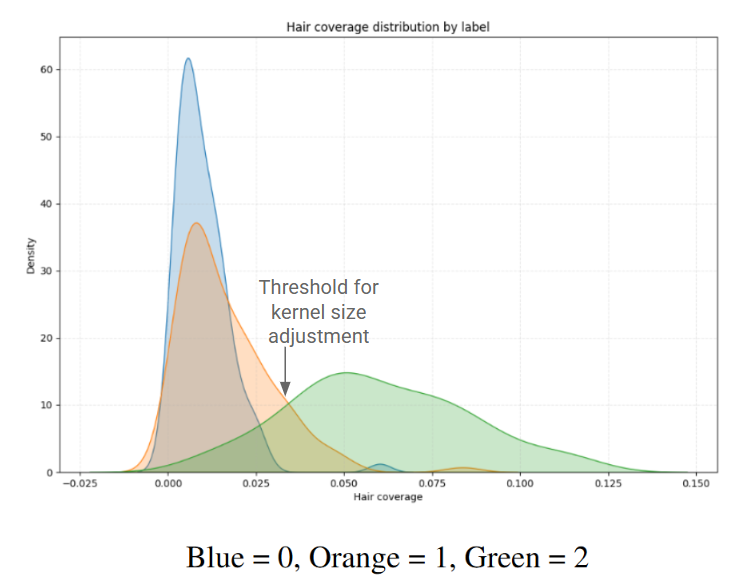

**Let's go back to the initial hair removal function and add the hair coverage adjustment**

In [ ]:
def removeHair_auto(img_org, img_gray):

    # Calculate hair coverage
    coverage = hair_coverage(img_gray)

    # Set parameters based on coverage
    # your code

    # kernel for the morphological filtering
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))

    # perform the blackHat filtering on the grayscale image to find the hair contours
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)

    # intensify the hair contours in preparation for the inpainting algorithm
    _, mask = cv2.threshold(blackhat, threshold, 255, cv2.THRESH_BINARY)

    # inpaint the original image depending on the mask
    img_out = cv2.inpaint(img_org, mask, radius, cv2.INPAINT_TELEA)

    return blackhat, mask, img_out

**Now let's test the function**

Hair coverage is high. Adjusting parameters for lots of hair.
Hair coverage is very low. Skipping hair removal.


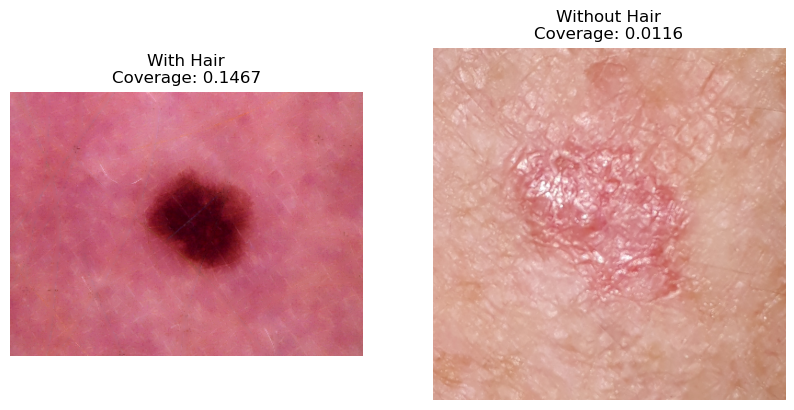

In [30]:
# Load image with hair
img_path_hair = 'black_hair.png'
img_org_hair = cv2.imread(img_path_hair)
img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)

# Load image without hair
img_path_nohair = 'no_hair.png'
img_org_nohair = cv2.imread(img_path_nohair)
img_gray_nohair = cv2.cvtColor(img_org_nohair, cv2.COLOR_BGR2GRAY)

# Test the auto hair removal function
_, _, img_out_1 = removeHair_auto(img_org_hair, img_gray_hair)
_, _,  img_out_2 = removeHair_auto(img_org_nohair, img_gray_nohair)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_out_1, cv2.COLOR_BGR2RGB))
plt.title(f'With Hair\nCoverage: {coverage_hair}')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_out_2, cv2.COLOR_BGR2RGB))
plt.title(f'Without Hair\nCoverage: {coverage_nohair}')
plt.axis('off')

plt.show()

# Explore on your own

This was just a brief introduction to hair removal, focusing on a simple case:
- Dark hair
- Perfect hair coverage threshold
- Clear image

As you explore your dataset, you will notice that some images are blurry, have a lot of hair, or contain wrinkles and other artifacts. If hair is present on the lesion, it becomes even harder to remove because it can blend with the lesion's colors.

For your project, you are encouraged to try different methods and develop your own hair removal strategies. You do not have to use only the techniques provided here, but you should be able to explain your methods on a high level.

In this week's folder, you will find example images showing other cases, such as white hair and a mix of white and dark hair. Feel free to use these for your experiments.


**Now try out the following tasks yourself:**
1. Experiment with the hair removal function on white and mixed color hair. Is there a function that we should consider changing? [Hint](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html).
2. Explore image enhancement techniques for better segmentation: [article](https://medium.com/@prajakta.dhole22/image-enhancement-techniques-in-digital-image-processing-b0cd4f957290).
3. Since penmarks look similar to hair in some cases, they can be removed using the same strategies. Find examples of images with penmarks and check if they are removed together with hair; otherwise, try creating a new function targeting penmarks specifically.